<a href="https://colab.research.google.com/github/fajareka1/PCVK_Ganjil_2026_v2/blob/main/Modul1_Tugas_Kelompok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum Kelompok — Modul 1
**Pengantar Citra Digital: Representasi, Karakteristik, dan Aplikasi dalam Visi Komputer**
Pengolahan Citra dan Visi Komputer — Jurusan Teknologi Informasi, Politeknik Negeri Malang

**Soal:**
1. Akses file image lokal (KTM) dan tampilkan menggunakan OpenCV dan Matplotlib.
2. Tutup tiap bagian tertentu dari KTM tersebut menggunakan fungsi yang telah dipelajari (rectangle, circle, dll). Kreasikan terkait dengan warna dan ukuran dari bentuk-bentuknya.

Pembagian bagian yang ditutup per kelompok (sesuai jobsheet):
| Kelompok | Bagian yang ditutup |
|---|---|
| 1 | NIM, nama, dan Prodi |
| 2 | Mata dan mulut pada foto mahasiswa |
| 3 | Tulisan POLITEKNIK NEGERI MALANG, BNI, dan Prodi |
| 4 | Tulisan Malang, POLINEMA, dan Barcode |
| 5 | Logo POLINEMA, tgl Valid Thru, dan tulisan D-IV |
| 6 | Tulisan Month/Year, tulisan Valid Thru, dan angkanya (3 bagian) |
| 7 | Prodi, Logo BNI, dan tulisan Politeknik Negeri Malang |
| 8 | Logo Polinema, tulisan BNI, dan Barcode |
| 9 | Wajah, NIM, dan angka Batas Studi |
| 10 | Logo BNI, tulisan BNI, dan Barcode |

## Langkah 1 — Import Library
Menggunakan pustaka yang sama seperti pada praktikum D2: `numpy`, `pandas`, `cv2` (alias `cv`), `cv2_imshow`, `skimage`, `PIL`, dan `matplotlib`.

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

try:
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    def cv2_imshow(img):
        # fallback untuk lingkungan non-Colab
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB) if img.ndim == 3 else img)
        plt.show()

print("Library siap digunakan. IN_COLAB =", IN_COLAB)

Library siap digunakan. IN_COLAB = True


## Langkah 2 — Akses File Image Lokal (KTM)

In [ ]:
from google.colab import files

uploaded = files.upload()  # <-- jalankan lalu pilih file KTM Anda di sini
print("File terupload:", list(uploaded.keys()))

Saving ktm.jpeg to ktm.jpeg
File terupload: ['ktm.jpeg']


### Menentukan nama file KTM yang dipakai

In [ ]:
import os

FILE_KTM = "ktm.jpeg"   # <-- ganti sesuai nama file KTM yang Anda upload

if FILE_KTM is not None and os.path.exists(FILE_KTM):
    print(f"File '{FILE_KTM}' ditemukan, siap digunakan.")
else:
    print(f"[!] File '{FILE_KTM}' belum tersedia. Upload dulu pada sel di atas, "
          f"lalu sesuaikan nama variabel FILE_KTM, kemudian jalankan ulang sel ini.")
    FILE_KTM = None

File 'ktm.jpeg' ditemukan, siap digunakan.


## Langkah 3 — Menampilkan Citra KTM (OpenCV & Matplotlib)

Resolusi gambar: 1500 x 912
Tampil dengan cv2_imshow() -> format BGR:


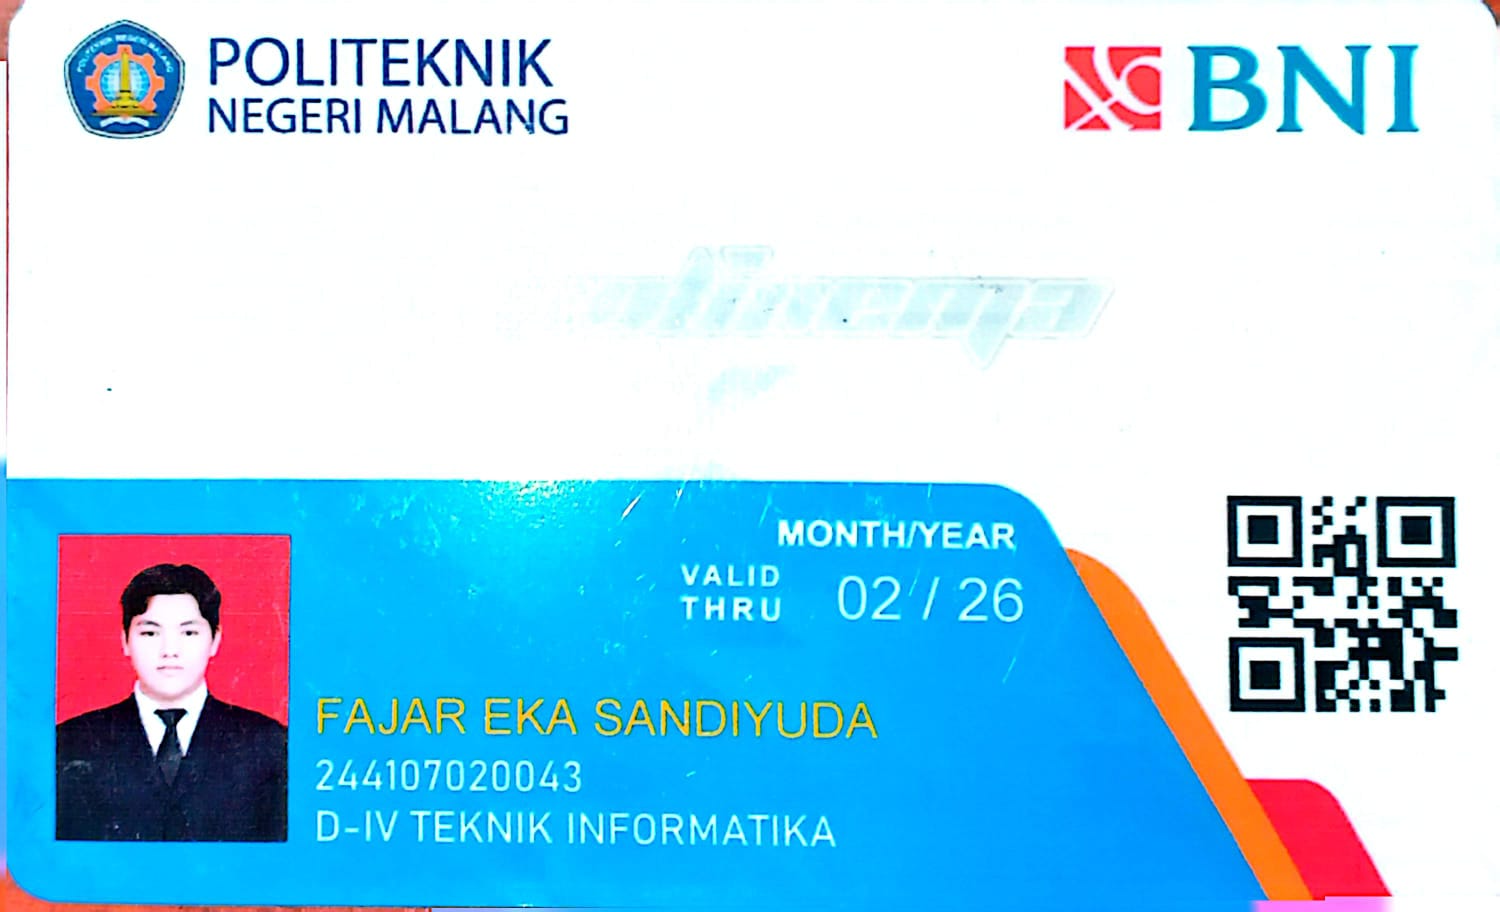

In [ ]:
if FILE_KTM:
    img = cv.imread(FILE_KTM)
    print("Resolusi gambar:", img.shape[1], "x", img.shape[0])

    print("Tampil dengan cv2_imshow() -> format BGR:")
    cv2_imshow(img)
else:
    print("Lewati: upload foto KTM terlebih dahulu.")

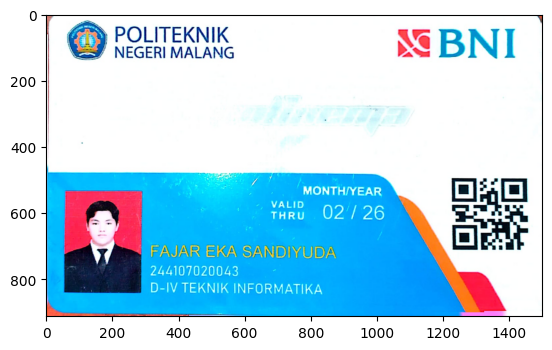

In [ ]:
if FILE_KTM:
    imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB
    plt.imshow(imgRGB)
    plt.show()
else:
    print("Lewati: upload foto KTM terlebih dahulu.")

## Langkah 4 — Menutup Bagian Tertentu pada KTM


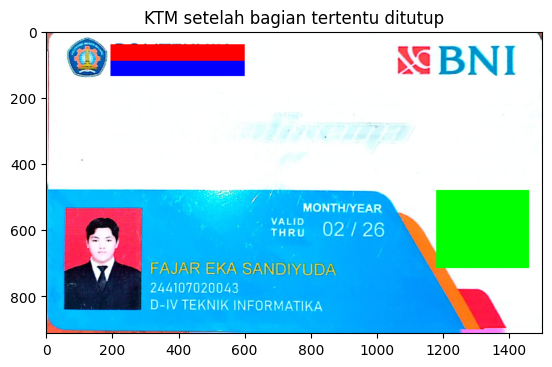

In [ ]:
if FILE_KTM:
    img_tertutup = img.copy()

    # AREA 1: Tutup tulisan "POLITEKNIK" (POLINEMA)
    pt1_1, pt2_1 = (195, 40), (600, 90)
    warna_1 = (0, 0, 255)
    cv.rectangle(img_tertutup, pt1=pt1_1, pt2=pt2_1, color=warna_1, thickness=-1)  # -1 = terisi penuh

    # AREA 2: Tutup tulisan "NEGERI MALANG"
    pt1_2, pt2_2 = (195, 90), (600, 135)
    warna_2 = (255, 0, 0)
    cv.rectangle(img_tertutup, pt1=pt1_2, pt2=pt2_2, color=warna_2, thickness=-1)

    # AREA 3: Tutup Barcode / QR Code
    pt1_3, pt2_3 = (1180, 480), (1460, 715)
    warna_3 = (0, 255, 0)
    cv.rectangle(img_tertutup, pt1=pt1_3, pt2=pt2_3, color=warna_3, thickness=-1)

    # Tampilkan hasil
    imgRGB_tertutup = cv.cvtColor(img_tertutup, cv.COLOR_BGR2RGB)
    plt.imshow(imgRGB_tertutup)
    plt.title("KTM setelah bagian tertentu ditutup")
    plt.show()
else:
    print("Lewati: upload foto KTM terlebih dahulu.")

### (Opsional) Menambahkan Teks di Atas Area yang Ditutup
Jika ingin menambahkan keterangan/label di atas area yang ditutup, gunakan `cv.putText()` seperti pada praktikum.

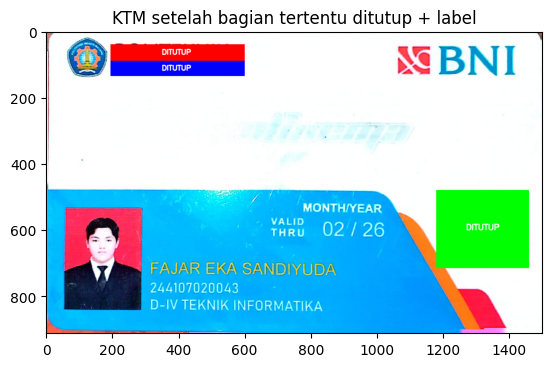

In [ ]:
if FILE_KTM:
    font = cv.FONT_HERSHEY_SIMPLEX

    # Label di AREA 1 (tulisan "POLITEKNIK")
    cv.putText(img_tertutup, text='DITUTUP', org=(350, 70), fontFace=font,
               fontScale=0.7, color=(255, 255, 255), thickness=2, lineType=cv.LINE_AA)

    # Label di AREA 2 (tulisan "NEGERI MALANG")
    cv.putText(img_tertutup, text='DITUTUP', org=(350, 118), fontFace=font,
               fontScale=0.7, color=(255, 255, 255), thickness=2, lineType=cv.LINE_AA)

    # Label di AREA 3 (Barcode / QR code)
    cv.putText(img_tertutup, text='DITUTUP', org=(1270, 600), fontFace=font,
               fontScale=0.8, color=(255, 255, 255), thickness=2, lineType=cv.LINE_AA)

    imgRGB_tertutup = cv.cvtColor(img_tertutup, cv.COLOR_BGR2RGB)
    plt.imshow(imgRGB_tertutup)
    plt.title("KTM setelah bagian tertentu ditutup + label")
    plt.show()
else:
    print("Lewati: upload foto KTM terlebih dahulu.")